In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [36]:
df = pd.read_csv("../data/loan_data.csv")

df.head()

,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_term,credit_history,property_area,loan_status
0,Male,Yes,0,Graduate,No,5849,0,128,360,1,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508,128,360,1,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0,66,360,1,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358,120,360,1,Urban,Y
4,Male,No,0,Graduate,No,6000,0,141,360,1,Urban,Y


In [37]:
df.describe()

,applicant_income,coapplicant_income,loan_amount,loan_term,credit_history
count,20.00000,20.000000,20.000000,20.0,20.000000
mean,5178.95000,1637.800000,165.850000,360.0,0.900000
std,2448.94524,2495.876254,72.364047,0.0,0.307794
min,2500.00000,0.000000,66.000000,360.0,0.000000
25%,3425.00000,0.000000,120.000000,360.0,1.000000
50%,4791.50000,1350.000000,140.500000,360.0,1.000000
75%,6000.00000,2000.000000,200.000000,360.0,1.000000
max,12841.00000,10968.000000,349.000000,360.0,1.000000


In [38]:
df.isnull().sum()

gender                0
married               0
dependents            0
education             0
self_employed         0
applicant_income      0
coapplicant_income    0
loan_amount           0
loan_term             0
credit_history        0
property_area         0
loan_status           0
dtype: int64

In [39]:
df.fillna(method="ffill", inplace=True)

C:\Users\amank\AppData\Local\Temp\ipykernel_22472\173857299.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


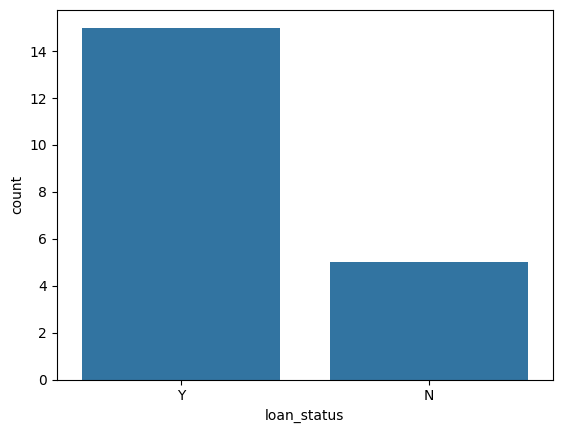

In [40]:
sns.countplot(x="loan_status", data=df)
plt.show()

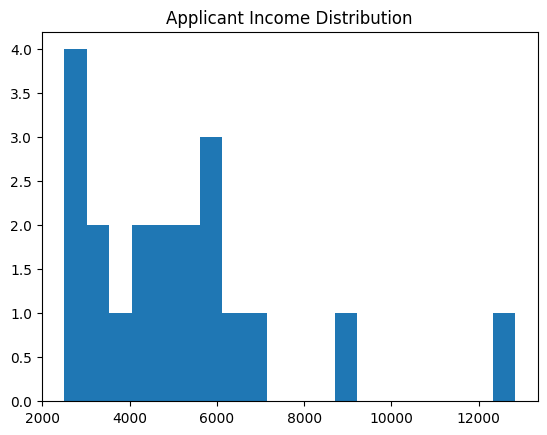

In [41]:
plt.hist(df["applicant_income"], bins=20)
plt.title("Applicant Income Distribution")
plt.show()

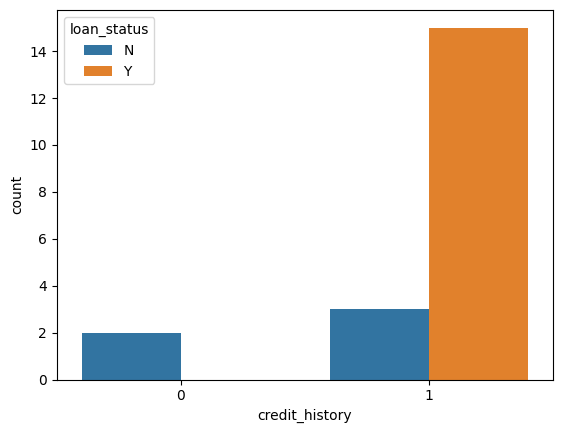

In [42]:
sns.countplot(x="credit_history", hue="loan_status", data=df)
plt.show()

In [43]:
le = LabelEncoder()

columns = [
    'gender',
    'married',
    'education',
    'self_employed',
    'property_area'
]

for col in columns:
    df[col] = le.fit_transform(df[col])

In [44]:
df['dependents'] = df['dependents'].replace('3+',3)
df['dependents'] = df['dependents'].astype(int)

In [45]:
df['loan_status'] = df['loan_status'].map({'Y':1,'N':0})

In [46]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [47]:
lr = LogisticRegression()
lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test,pred_lr))

Logistic Accuracy: 0.75


C:\Users\amank\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [48]:
dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test,pred_dt))

Decision Tree Accuracy: 0.75


In [49]:
rf = RandomForestClassifier()

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test,pred_rf))

Random Forest Accuracy: 0.75


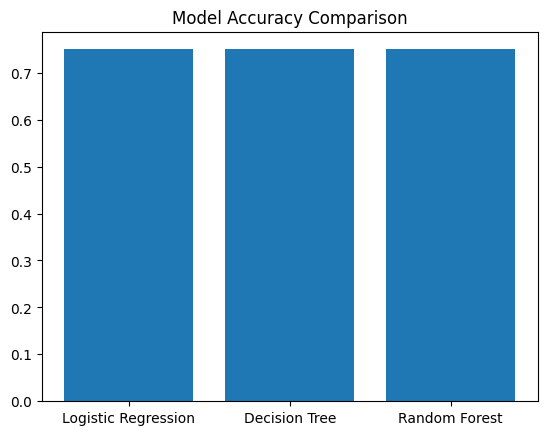

In [50]:
models = ["Logistic Regression","Decision Tree","Random Forest"]

scores = [
accuracy_score(y_test,pred_lr),
accuracy_score(y_test,pred_dt),
accuracy_score(y_test,pred_rf)
]

plt.bar(models,scores)
plt.title("Model Accuracy Comparison")
plt.show()

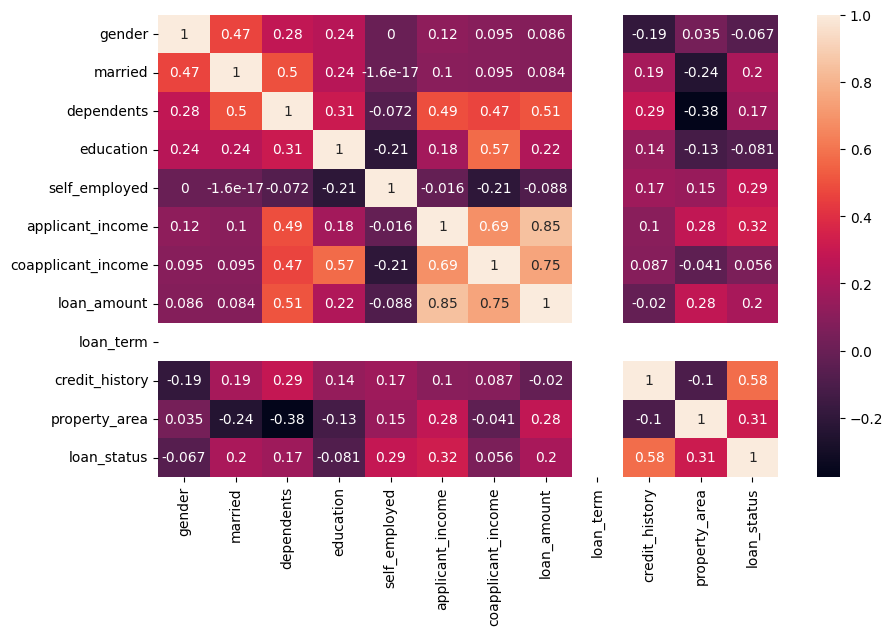

In [51]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()